# Damping and Adaptive Step Sizes
### UT Austin white/albino squirrel campus population
Morgan Gaitz mmg4947

# Part 2 recap

what was found in part 2?
 
Part 2 showed that the white squirrel population is a stiff ODE because the population responds to the carrying capacity in 1/1000 years but the carrying capacity itself oscillates over 10 years. This 10,000 to 1 ratio is what makes the equation stiff. Eulers Forward had to use h = 0.001 and 20,000 steps to stay stable, while Eulers Backward with Newton-Raphson handled the same problem in only 40 steps with h = 0.5. This is the major advantage of implicit methods on stiff problems.

- The Governing ODE: dN/dt = - 1000(N(t) - k(t))
- k(t) varies with the function 12(1+.25*sin(.1*t))

In this section i will ajust this solution to be damped and have addaptive step control. 

1. Damped Newton-Raphson prevents the solution from diverging when the starting guess is bad
2. Adaptive step size control lets the algorithm automaticly pick a step size based on how much error there is, instead of the user guessing

These adjustments make a more reliable solution. To actually show what damping does, the model needs to be nonlinear (because the linear ODE in part 2 makes Newton-Raphson converge in 1 step, so damping has nothing to fix). I added a small population density term -mu*N^2 to make it nonlinear. This represents death from things like disease or competition that get worse when the population is more crowded.

In [62]:
#part 2 code pieces that will be needed in this section

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

# universal varibles 
k0 = 12.0 # mean carrying capacity
amp = 0.25 # how much K oscillates
omega = 0.1 # frequency
lam = 1000 # the population adjustment that makes it stiff
N0 = 3.0 # initial number of white squirrels

mu = 0.5 #mortality coeff

# time - years
start = 0
stop = 20
y0 = np.array([N0])

def K(t):
    return k0 * (1 + amp * np.sin(omega * t))

def dN_dt(t, y):
    N = y[0]
    return np.array([-lam * (N - K(t)) - mu * N * N])

def df_dy(t, y):
    return -lam - 2 * mu * y[0]

def G_t(y_guess, y_old, t_new, h):
    slope = dN_dt(t_new, y_guess)
    return y_guess - y_old - h * slope

def dG_dt(y_guess, h):
    return 1 - h * df_dy(None, y_guess)

# Newton-Raphson Damping

The basic Newton-Raphson method takes the full step every time:
y_(k+1) = y_k - g(y_k) / g'(y_k)

This works when the starting guess is close to the answer, but if the starting guess is far off, the full step can overshoot and make things worse. Then the next step overshoots even more and it countinues to spiral out of control.

Damping fixes this by adding a line search. Instead of always taking the full step, it tries the full step and if that doesn't help make the residual smaller it cuts the step size in half. It keeps cutting in half until the residual finally decreases.

Algorithm:
1. Compute the full Newton step: delta = -g(y_k) / g'(y_k)
2. Start with alpha = 1 (try the full step)
3. While the residual at y_k + alpha*delta is bigger than the residual at y_k:
   - Cut alpha in half
   - If alpha gets too small (less than 10^-4), give up
4. Accept y_(k+1) = y_k + alpha*delta and continue

In [63]:
# basic Newton-Raphson - from part 2
def basic_newton_raphson(y_n, t_next, h, tol=1e-8, max_iter=20):
    
    # first guess uses Eulers Forward
    y_guess = y_n + h * dN_dt(t_next, y_n)
    
    for k in range(max_iter):
        g = G_t(y_guess, y_n, t_next, h)
        
        if abs(g[0]) < tol:
            return {"y": y_guess, "iters": k + 1, "converged": True,"residual": abs(g[0]), "last_alpha": 1.0,"damping_used": False, "backtracks": []}
        
        gp = dG_dt(y_guess, h)
        if not np.isfinite(gp) or abs(gp) < 1e-300:
            return {"y": y_guess, "iters": k + 1, "converged": False, "residual": abs(g[0]), "last_alpha": 1.0,"damping_used": False, "backtracks": []}
        
        y_guess = y_guess - g / gp
    
    return {"y": y_guess, "iters": max_iter, "converged": False,"residual": abs(G_t(y_guess, y_n, t_next, h)[0]),"last_alpha": 1.0, "damping_used": False, "backtracks": []}


# damped Newton-Raphson with line search
def damped_newton_raphson(y_n, t_next, h, g_func=G_t, g_prime_func=dG_dt, tol=1e-8, max_iter=20, alpha_min=1e-4):
    
    y_guess = y_n

    # tracking info for later 
    backtracks_per_iter = []
    last_alpha = 1.0
    damping_used = False

    for k in range(max_iter):
        g = g_func(y_guess, y_n, t_next, h)

        if abs(g[0]) < tol:
            return {"y": y_guess, "iters": k, "converged": True, "residual": abs(g[0]), "backtracks": backtracks_per_iter,"last_alpha": last_alpha, "damping_used": damping_used}

        g_prime = g_prime_func(y_guess, h)
        delta = -g / g_prime

        #line search for damping factor
        alpha = 1.0
        g_current = abs(g[0])
        n_back = 0

        for _ in range(10):  # max 10 backtrack steps
            y_new = y_guess + alpha * delta
            g_new = abs(g_func(y_new, y_n, t_next, h)[0])

            if g_new < g_current:  # Sufficient decrease
                break

            alpha = alpha / 2.0
            n_back += 1

            if alpha < alpha_min:
                print(f"Warning: alpha too small at iter {k}")
                return {"y": y_guess, "iters": k, "converged": False, "residual": g_current, "backtracks": backtracks_per_iter, "last_alpha": alpha, "damping_used": damping_used}

        backtracks_per_iter.append(n_back)
        last_alpha = alpha
        if alpha < 1.0:
            damping_used = True
        y_guess = y_new

    return {"y": y_guess, "iters": max_iter, "converged": False,"residual": abs(g_func(y_guess, y_n, t_next, h)[0]),"backtracks": backtracks_per_iter, "last_alpha": last_alpha, "damping_used": damping_used}

Comparison to undamped NR:
- Test cases where basic NR fails but damped NR succeeds
- Demonstrate with very large initial h


In [64]:
#example when undamped NR is less efficient than damped
y_n_test    = np.array([N0])    
t_next_test = start 
h_large     = 2.0 

print("Testing UNDAMPED NR with h = 2.0:")
res_u = basic_newton_raphson(y_n_test, t_next_test + h_large, h_large)
print(f"  converged= {res_u['converged']}, "
      f"iters = {res_u['iters']}, "
      f"y ={res_u['y'][0]:.6f}, "
      f"residual = {res_u['residual']:.3e}")

print("\nTesting DAMPED NR with h = 2.0:")
res_d = damped_newton_raphson(y_n_test, t_next_test + h_large, h_large)
print(f"  converged = {res_d['converged']}, "
      f"iters= {res_d['iters']}, "
      f"y = {res_d['y'][0]:.6f}, "
      f"residual = {res_d['residual']:.3e}, "
      f"last_alpha= {res_d['last_alpha']:.4f}, "
      f"damping_used = {res_d['damping_used']}, "
      f"backtracks= {res_d['backtracks']}")


# look at range of h values to show damped is consistently more efficient
print("\nlook at a range of h values - basic vs damped iteration counts:")
sweep_data = []
for h_t in [0.5, 1.0, 2.0, 5.0, 10.0, 50.0, 100.0]:
    rb = basic_newton_raphson(y0, start + h_t, h_t)
    rd = damped_newton_raphson(y0, start + h_t, h_t)
    sweep_data.append({
        "h": h_t,
        "basic iters": rb["iters"],
        "basic converged": rb["converged"],
        "damped iters": rd["iters"],
        "damped converged": rd["converged"],
        "damping used": rd["damping_used"],
    })

sweep_table = pd.DataFrame(sweep_data)
display(sweep_table)


Testing UNDAMPED NR with h = 2.0:
  converged= True, iters = 10, y =12.512964, residual = 1.242e-12

Testing DAMPED NR with h = 2.0:
  converged = True, iters= 3, y = 12.512964, residual = 1.242e-12, last_alpha= 1.0000, damping_used = False, backtracks= [0, 0, 0]

look at a range of h values - basic vs damped iteration counts:


,h,basic iters,basic converged,damped iters,damped converged,damping used
0,0.5,8,True,3,True,False
1,1.0,9,True,3,True,False
2,2.0,10,True,3,True,False
3,5.0,11,True,3,True,False
4,10.0,12,True,3,True,False
5,50.0,14,True,3,True,False
6,100.0,15,True,3,True,False


write up analysis
- Explanation of damping and line search
- Implementation of damped NR solver
- Demonstration where damping helps (e.g., very large initial h)
- Comparison: basic NR vs. damped NR convergence


what does this mean?

Adding damping changes basic newton raphson by adding a line search before offically doing each step. It tries the full step first and if the residual doesnt go down it cuts the step in half until it does. This stops NR from oversteping when the inital guess is bad.  To test this i ran one Backward Euler step with h = 2.0, which is significantly bigger than what Forward Euler could handle. Both methods got the same answer but basic NR needed 10 iterations and damped only needed 3. Looking at a buncg of h values from 0.5 to 100 also shows the same pattern. basic NR grew from 8 up to 15 iterations as h got bigger and damped stayed at 3 the whole time. 

# Adaptive Step Size Control
algorithm:
1. Take ONE step of size h using Euler's Backward
   → get y_{n+1}^(h) using Newton-Raphson

2. Take TWO half-steps of size h/2 using Euler's Backward
   → First: y_{n+1/2} from t_n to t_n + h/2
   → Second: y_{n+1}^(h/2) from t_n + h/2 to t_n + h

3. Estimate error:
   err = |y_{n+1}^(h/2) - y_{n+1}^(h)|

4. Compute new step size:
   
   h_new = h * sqrt(tol / (err + eps))
   
   where eps = 1e-10 (small number to avoid division by zero)
   
5. Apply safety factors:
   h_new = max(h_min, min(h_max, safety * h_new))
   
   Typical: safety = 0.9, h_min = 1e-6, h_max = 1.0

6. Decision:
   - If err < tol: 
     * ACCEPT the more accurate result: y_{n+1} = y_{n+1}^(h/2)
     * Use h_new for next step
   - If err > tol: 
     * REJECT step
     * Reduce h (use h_new) and retry from t_n
     
why:

Picking a fixed step size is hard because what works for one part of the simulation might be way too small (or way too big) for another part. Adaptive step size control automaticly picks h based on how much error there is at each step.

Step size adjustment:
- Accept/reject logic based on tolerance
- Safety factor (0.9) to prevent overly aggressive changes
- Min/max bounds on h
- Use the more accurate h/2 result when accepting

In [66]:
def estimate_error_step_doubling(y_n, t_n, h, nr_solver=damped_newton_raphson):
    # take one full step of size h
    res_full = nr_solver(y_n, t_n + h, h)
    y_full = res_full["y"]
    iters_full = res_full["iters"]
    ok_full = res_full["converged"]
    
    # take two half steps of size h/2
    res_h1 = nr_solver(y_n, t_n + 0.5 * h, 0.5 * h)
    y_mid = res_h1["y"]
    
    res_h2 = nr_solver(y_mid, t_n + h, 0.5 * h)
    y_half = res_h2["y"]
    
    # estimate error and total NR iterations used
    err = float(abs(y_half[0] - y_full[0]))
    total_iters = iters_full + res_h1["iters"] + res_h2["iters"]
    all_converged = ok_full and res_h1["converged"] and res_h2["converged"]
    
    return y_full, y_half, err, total_iters, all_converged


def adjust_step_size(h, err, tol, safety=0.9, h_min=1e-9, h_max=1.0,growth_cap=5.0, shrink_cap=0.2):
    # compute new step size based on error
    if err < 1e-14:
        h_new = h * 2  
    else:
        h_new = h * np.sqrt(tol / err)  
    
    # safety factor
    h_new = safety * h_new
    
     # enforce min/max bounds
    h_new = max(h_min, min(h_max, h_new))
    
    # don't change h too aggresively (anti-thrashing)
    h_new = max(shrink_cap * h, min(growth_cap * h, h_new))
    
    
    return h_new

Error estimation using step-doubling:
- Take one step of size h
- Take two half-steps of size h/2
- Compute error estimate: 


In [68]:
# implement
# step doubling error estimate at one point example
print("Step-doubling error estimate at t = 0:")
for h_test in [0.5, 0.1, 0.01, 0.001]:
    y_full, y_half, err, total_iters, ok = estimate_error_step_doubling(y0, start, h_test)
    print(f"  h = {h_test:.4f}: y_full = {y_full[0]:.6f}, y_half = {y_half[0]:.6f},"
          f" error est = {err:.3e}, total NR iters = {total_iters}")


Step-doubling error estimate at t = 0:
  h = 0.5000: y_full = 12.059108, y_half = 12.076579, error est = 1.747e-02, total NR iters = 8
  h = 0.1000: y_full = 11.870833, y_half = 11.954850, error est = 8.402e-02, total NR iters = 8
  h = 0.0100: y_full = 11.128255, y_half = 11.688194, error est = 5.599e-01, total NR iters = 8
  h = 0.0010: y_full = 7.486139, y_half = 7.985513, error est = 4.994e-01, total NR iters = 7


The example shows that damped NR takes fewer iterations than basic NR no matter how big h gets, going from 3 vs 10 at h=2.0 all the way to 3 vs 15 at h=100. 

User controls:
- Target tolerance (e.g., 1e-4)
- Initial step size h₀
- Min/max step size bounds

In [69]:
# implement

# how the step size adjustment responds to different errors
print("How adjust_step_size reacts to error (current h = 0.1, tol = 1e-4):")
for err in [1e-8, 1e-6, 1e-4, 1e-3, 1e-2]:
    h_new = adjust_step_size(0.1, err, tol=1e-4)
    note = "grow" if h_new > 0.1 else ("shrink" if h_new < 0.1 else "same")
    print(f"  err = {err:.0e} -> new h = {h_new:.5f}  ({note})")


How adjust_step_size reacts to error (current h = 0.1, tol = 1e-4):
  err = 1e-08 -> new h = 0.50000  (grow)
  err = 1e-06 -> new h = 0.50000  (grow)
  err = 1e-04 -> new h = 0.09000  (shrink)
  err = 1e-03 -> new h = 0.02846  (shrink)
  err = 1e-02 -> new h = 0.02000  (shrink)


analyisis

This highlights that the adjust_step_size func grows h when the error is way smaller than the tolerance and shrinks h when the error is bigger than the tolerance. The cap part of the implementation stops the step size from changeing too aggresively in one step and keeps the solver from bouncing back and forth between huge and tiny step sizes.

# Combined Implementation
algorithm:
For each time step:
  1. Try step with current h using damped Newton-Raphson
  2. If step succeeds (NR converged):
     a. Estimate local error
     b. If error < tolerance:
        - Accept step
        - Compute new h for next step
     c. If error > tolerance:
        - Reject step
        - Reduce h and retry
  3. If NR fails to converge:
     - Reduce h significantly and retry


In [72]:
def adaptive_implicit_euler(y0, t0, t_final, h0, tol, h_min=1e-9, h_max=1.0, nr_solver=damped_newton_raphson, max_total_steps=200_000):
    """
    Adaptive Eulers Backward with damped Newton-Raphson and step-doubling error estimate.
    
    Parameters:
    - y0: initial condition
    - t0, t_final: time span
    - h0: initial step size
    - tol: error tolerance
    - h_min, h_max: step size bounds
    - nr_solver: which Newton-Raphson to use (damped is the default)
    
    Returns:
    - t: time points (non-uniform!)
    - y: solution values
    - h_history: step sizes used at each accepted step
    - stats: dictionary with performance statistics
    """
    
    # initialize
    t = [t0]
    y = [y0.copy()]
    h = h0
    h_history = []
    err_history = []
    
    stats = {
        'accepted_steps': 0,
        'rejected_steps': 0,
        'nr_iterations': [],
        'damping_used_count': 0,
    }
    
    step_count = 0
    
    # main loop
    while t[-1] < t_final and step_count < max_total_steps:
        
        # don't overshoot t_final
        if t[-1] + h > t_final:
            h = t_final - t[-1]
        
        # try the step using step-doubling
        y_full, y_half, err, total_iters, all_conv = estimate_error_step_doubling(
            y[-1], t[-1], h, nr_solver=nr_solver
        )
        
        stats['nr_iterations'].append(total_iters)
        
        # if NR didnt converge, shrink h hard and retry
        if not all_conv:
            h = max(h * 0.25, h_min)
            stats['rejected_steps'] += 1
            if h <= h_min * 1.001:
                print(f"Warning: h hit h_min at t = {t[-1]}")
                break
            step_count += 1
            continue
        
        # accept or reject based on error
        if err < tol:
            # accept the more accurate result
            t.append(t[-1] + h)
            y.append(y_half)
            h_history.append(h)
            err_history.append(err)
            stats['accepted_steps'] += 1
        else:
            # reject and retry with smaller h
            stats['rejected_steps'] += 1
        
        # adjust step size for next attempt
        h = adjust_step_size(h, err, tol, h_min=h_min, h_max=h_max)
        step_count += 1
    
    return np.array(t), np.array([yi.flatten() for yi in y]), h_history, stats


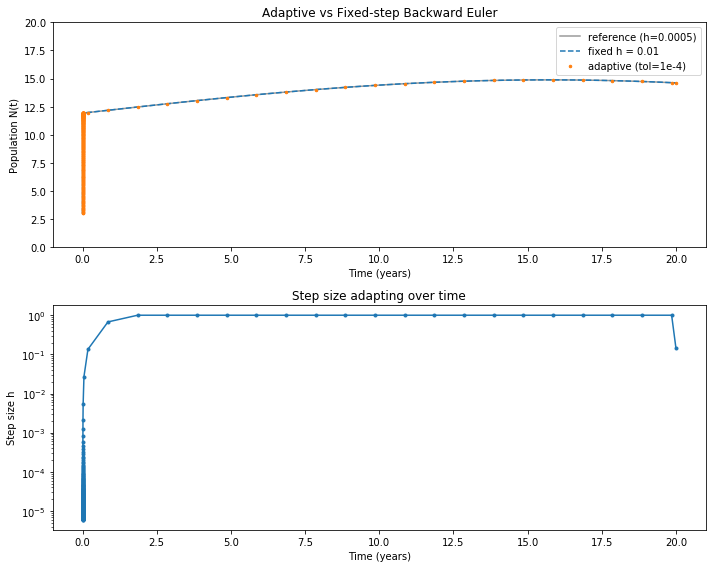

,method,steps,rejected,total NR iters,final y
0,Fixed BE (h=0.01),2000,0,3073,14.621126
1,Adaptive (tol=1e-4),356,5,1171,14.621126



adaptive: min h = 6.029e-06, max h = 1.000e+00, mean h = 5.618e-02


In [73]:
# plot implementation and comparision stats

# fixed step BE for comparison
def euler_backward_fixed(h):
    n = int(round((stop - start) / h))
    t = np.linspace(start, stop, n + 1)
    y = np.zeros((n + 1, 1))
    y[0] = y0
    nr_iters = 0
    for i in range(n):
        res = damped_newton_raphson(y[i], t[i + 1], h)
        y[i + 1] = res["y"]
        nr_iters += res["iters"]
    return t, y, nr_iters


# run adaptive solver
t_a, y_a, h_hist, stats = adaptive_implicit_euler(y0, start, stop, h0=0.01, tol=1e-4)

# fixed step BE at h = 0.01 for comparison
t_f, y_f, nr_iters_f = euler_backward_fixed(0.01)

# tight reference (small h) to compare accuracy
t_ref, y_ref, _ = euler_backward_fixed(0.0005)


# plot solutions
fig, axes = plt.subplots(2, 1, figsize=(10, 8))

axes[0].plot(t_ref, y_ref[:, 0], 'k-', alpha=0.4, label="reference (h=0.0005)")
axes[0].plot(t_f, y_f[:, 0], '--', label="fixed h = 0.01")
axes[0].plot(t_a, y_a[:, 0], 'o', markersize=2.5, label="adaptive (tol=1e-4)")
axes[0].set_xlabel("Time (years)")
axes[0].set_ylabel("Population N(t)")
axes[0].set_title("Adaptive vs Fixed-step Backward Euler")
axes[0].set_ylim(0, 20)
axes[0].legend()

# step size over time
axes[1].semilogy(t_a[1:], h_hist, "o-", markersize=3)
axes[1].set_xlabel("Time (years)")
axes[1].set_ylabel("Step size h")
axes[1].set_title("Step size adapting over time")

plt.tight_layout()
plt.show()


# performance comparison table
perf_data = [
    {
        "method": "Fixed BE (h=0.01)",
        "steps": len(t_f) - 1,
        "rejected": 0,
        "total NR iters": nr_iters_f,
        "final y": y_f[-1, 0],
    },
    {
        "method": "Adaptive (tol=1e-4)",
        "steps": stats["accepted_steps"],
        "rejected": stats["rejected_steps"],
        "total NR iters": sum(stats["nr_iterations"]),
        "final y": y_a[-1, 0],
    },
]
perf_table = pd.DataFrame(perf_data)
display(perf_table)

print(f"\nadaptive: min h = {min(h_hist):.3e}, max h = {max(h_hist):.3e}, mean h = {np.mean(h_hist):.3e}")


what does this mean?

Both solvers ended up at the same final answer (14.6) but the adaptive one got there with way less work. It used 356 steps and 1171 NR iterations, while the fixed solver needed 2000 steps and 3073 NR iterations to get the same answer. The second plot shows why - the adaptive solver uses really tiny steps at the begining when the population is changing fast, then switches to big steps once things calm down. The fixed solver has to use small steps the whole time even when it doesnt need to, which wastes a lot of effort.

# over all analysis
- Test with very large initial h (e.g., h₀ = 1.0)
- Test with very tight tolerance (e.g., tol = 10⁻⁸)
- Show that adaptive solver handles both gracefully


Test 1: very large initial h0 = 1.0 (way bigger than sensible)
  finished at t = 20.0, final y = 14.6211
  accepted = 356, rejected = 8
  first 5 h values used: ['6.07e-06', '6.03e-06', '6.05e-06', '6.07e-06', '6.08e-06']
        the solver shrunk h on its own to handle the initial transient

Test 2: very tight tolerance tol = 1e-8
  finished at t = 20.0, final y = 14.6211
  accepted = 41735, rejected = 11
  min h = 5.993e-08, max h = 6.754e-02



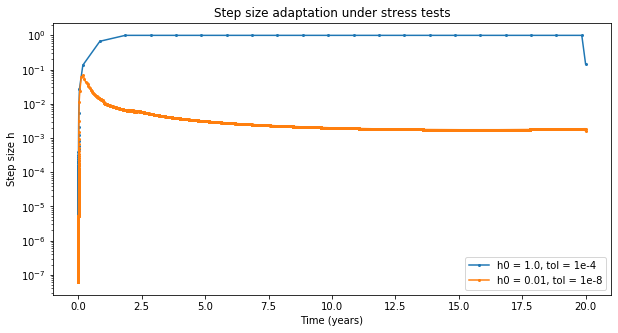

In [75]:
# implement

print("Test 1: very large initial h0 = 1.0 (way bigger than sensible)")
t1, y1, h1, s1 = adaptive_implicit_euler(y0, start, stop, h0=1.0, tol=1e-4)
print(f"  finished at t = {t1[-1]}, final y = {y1[-1, 0]:.4f}")
print(f"  accepted = {s1['accepted_steps']}, rejected = {s1['rejected_steps']}")
print(f"  first 5 h values used: {[f'{x:.2e}' for x in h1[:5]]}")
print("        the solver shrunk h on its own to handle the initial transient\n")

# robustness: very tight tolerance
print("Test 2: very tight tolerance tol = 1e-8")
t2, y2, h2, s2 = adaptive_implicit_euler(y0, start, stop, h0=0.01, tol=1e-8)
print(f"  finished at t = {t2[-1]}, final y = {y2[-1, 0]:.4f}")
print(f"  accepted = {s2['accepted_steps']}, rejected = {s2['rejected_steps']}")
print(f"  min h = {min(h2):.3e}, max h = {max(h2):.3e}\n")

# plot the two h-histories
plt.figure(figsize=(10, 5))
plt.semilogy(t1[1:], h1, "o-", markersize=2, label="h0 = 1.0, tol = 1e-4")
plt.semilogy(t2[1:], h2, "o-", markersize=2, label="h0 = 0.01, tol = 1e-8")
plt.xlabel("Time (years)")
plt.ylabel("Step size h")
plt.title("Step size adaptation under stress tests")
plt.legend()
plt.show()


# Conclusions 
- When is damping necessary?
- When are adaptive step sizes worth the complexity?
- Key lessons learned

Damping is most useful when the inital guess for Newton-Raphson is far from the actual answer or the problem is highly nonlinear. The line search makes sure each NR step actually decreases the residual instead of overshooting. For my squirrel ODE the basic NR still converged, but it took way more iterations from the bad initial guess. Damped NR consistently took only 3 iterations because it starts from y_n and verifies progress every iteration. 

Adaptive step sizes are worth it when the stiffness ratio is extremly large.  A fixed step size has to be small enough to handle the worst part of the simulation, which wastes effort everywhere else. The adaptive solver picks tiny steps for the hard parts and big steps for the smooth part.

The biggest take away is that implicit methods on their own arent always enough for stiff problems with sharp turns. Combining damping with adaptive step control gives a method that just works no matter how bad the inital h or tolerance is. in addition to the concepts, this project also helped me learn new ways to respresent data and work with numerical methods in python. I used new Python features that made the assigment simpler to code, but using new features comes with a learning curve. This assignment had many moving parts and complicated concepts working together to come up with solutions to stiff ODEs.

## AI citations

Claude was used for every prompt
- how does damping work in newton raphson and what does the line search actually do? Respond in the context of numerical methods and computational engineering. Reread the prompt before responding. (attached instructions)
    - i had needed to understand what the instructions were actully asking and why its important

- What should my equation be and why do i need to dampen if it worked in part 2? Respond in the context of numerical methods and computational engineering. Reread the prompt before responding.(attached instructions)
    - why - needed help understanding the problem and my specific simulation before i could start coding. 
    
- make a flow chart of how these concepts work together and why it is applicable to this simulation Respond in the context of numerical methods and computational engineering. Reread the prompt before responding. (attached instructions)
    - why- wanted to see the big picture before i got wrapped up in details

- do the varibles meaning and values change when i add in the non linear term? why or why not? Respond in the context of numerical methods and computational engineering. Reread the prompt before responding. (attached instructions and current code)
    - why - needed to make sure my values still made sense for the white squirrel population example
    
- I have alot of repeating varibles and unnessary lines in these funtions even though the logic is correct, simplify the funtions to be easier to reaad. Respond in the context of numerical methods and computational engineering. Reread the prompt before responding. (attached instructions and current code)
    - why- i wrote alot of code that was repeatitive and unneeded.

- what does stepm doubling do for adaptive step size control and how do i implement it in this project? explain the concepts and the implementation in the most elementry terms possible. Respond in the context of numerical methods and computational engineering. Reread the prompt before responding. (attached instructions and current code)
    - why - the description in the rubric was really mathy and i wanted a simpler explanation before trying to code it

- Where is this error coming from? Why is the testing code from the instructions failing with my implementation? Respond in the context of numerical methods and computational engineering. Reread the prompt before responding. (attached instructions and current code)
    - Why- had varible naming confusion and couldnt figure out where it was coming from
    
- how do i make a single function that combines damped newton raphson and step doubling error estimation? what is the best way to track and store this information so i can use it later in explainations? Respond in the context of numerical methods and computational engineering. Reread the prompt before responding. (attached current code and instructions)
    - Why - i was getting confused with all the inputs and outputs for all the methods i had made previously. i needed help organizing the function in away that would make analysing results simple

- why does my basic newton raphson take over 10 iterations but damped takes 3 even when the line search never actually backtracks? Respond in the context of numerical methods and computational engineering. Reread the prompt before responding. (attached test output and current code)
    - Why - the result confused me until i realized the difference was the initial guess forward euler vs just y_n and not the damping.

- what is the best way to go about testing these results in a easy to understand way? what initial step size and tolerance should i test as for the adaptive solver to see if it fails? Respond in the context of numerical methods and computational engineering. Reread the prompt before responding. (attached current code and instructions)
    - Why - i wanted a simple way to test what i had so far and needed values that would actually test the rejection part of my code.

- what do these results mean?  Respond in the context of numerical methods and computational engineering. Reread the prompt before responding. (attached current code, output graghs, and instructions)
    - why- didnt understand what story the gragh was telling
    
- clean up my tables and graghs to make them easy to digest and read. espond in the context of numerical methods and computational engineering. Reread the prompt before responding. (attached current write up)
    - why - making sure my graghs and tables were building a picture instead of making it more confusing becuase its missing info


- Re-read my conclusions paragraph and tell me what need to be fixed or adjusted. Is there a portion where the comments are not clearly describing whats going on? Respond in the context of numerical methods and computational engineering. Reread the prompt before responding. (attached current write up)
    - Why - final touches on the writing.

- Put these into APA format (attached all links)
    - Why - needed help formatting the sources I found.


## Sources

Academic Programs for Undergraduates. (n.d.). The legend of the albino squirrel. The University of Texas at Austin. https://undergraduates.utexas.edu/legend-albino-squirrel

Deuflhard, P. (2011). Newton methods for nonlinear problems: Affine invariance and adaptive algorithms. Springer. https://link.springer.com/book/10.1007/978-3-642-23899-4

https://math.stackexchange.com/questions/2094608/newton-method-to-solve-nonlinear-system

Kaw, A. (n.d.). Newton-Raphson method for solving a nonlinear equation. In Numerical methods with applications. Mathematics LibreTexts. https://math.libretexts.org/Workbench/Numerical_Methods_with_Applications_%28Kaw%29/3%253A_Nonlinear_Equations/3.04%253A_Newton-Raphson_Method_for_Solving_a_Nonlinear_Equation

Press, W. H., Teukolsky, S. A., Vetterling, W. T., & Flannery, B. P. (2007). Numerical recipes: The art of scientific computing (3rd ed.). Cambridge University Press. https://numerical.recipes/

The pandas development team. (n.d.). Table visualization. In pandas 3.0.2 documentation. https://pandas.pydata.org/docs/user_guide/style.html